In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os

In [5]:
folder = "data"
housing_data = "housing.data"
housing_names = "housing.names"

housing_data_paths = os.path.join(folder, housing_data)
housing_names_paths = os.path.join(folder, housing_names)

with open(housing_data_paths, 'r', encoding='utf-8') as file:
    arr = []
    for row in file:
        arr.append([float(n) for n in row.strip().split()])
    arr = np.array(arr)

names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS",
         "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]


training_data_X = arr[:100, :13]
training_data_Y = arr[:100, -1]
test_data_X = arr[100:, :13]
test_data_Y = arr[100:, -1]

train_df = pd.DataFrame(arr[:100, :], columns=names)
    

In [6]:
def design_matrix(A, order):
    ROWS, COLS = A.shape
    cols = [[1 for _ in range(ROWS)]] # add bias first
    for c in range(COLS):
        for power in range(1, order + 1):
            col = []
            for r in range(ROWS):
                col.append(A[r, c] ** power)
            cols.append(col)

    design_matrix = np.column_stack(cols)
    return design_matrix


In [7]:
def fit_normalizer(X):
    mean = X.mean(axis=0) # average cols
    std = X.std(axis=0) # standard deviation of all cols
    std[std==0] = 1 # no divide by zero
    return mean, std

def normalize(X, mean, std):
    return (X - mean) / std


In [8]:
mean, std = fit_normalizer(training_data_X)
training_data_Xn = normalize(training_data_X, mean, std)
test_data_Xn = normalize(test_data_X, mean, std)
print(training_data_Xn)

[[-0.71543301  0.24571498 -1.38525338 ... -2.00542571  0.42563837
  -1.02141254]
 [-0.66121648 -0.54197328  0.12753853 ... -0.5264982   0.42563837
  -0.2879153 ]
 [-0.66126814 -0.54197328  0.12753853 ... -0.5264982   0.27627869
  -1.18891792]
 ...
 [-0.41965715 -0.54197328 -1.20092159 ... -0.40818399  0.42563837
  -1.15718006]
 [-0.52028965 -0.54197328 -1.20092159 ... -0.40818399  0.30196709
  -1.27002579]
 [-0.55456566 -0.54197328 -1.20092159 ... -0.40818399  0.42563837
  -0.80806358]]


In [9]:
def fit(Phi, y):
    # least square weights for Phi
    w, _, _, _ = np.linalg.lstsq(Phi, y, rcond=None)
    return w

def rms_error(Phi, w, y):
    return np.sqrt(np.mean((Phi @ w - y) ** 2))


In [10]:
train_errors = []
test_errors = []
for order in range(1, 8):
    Phi_train = design_matrix(training_data_Xn, order)
    Phi_test = design_matrix(test_data_Xn, order)

    #do least squares
    w = fit(Phi_train, training_data_Y)

    # score
    train_rms = rms_error(Phi_train, w, training_data_Y)
    test_rms = rms_error(Phi_test, w, test_data_Y)
    
    train_errors.append(train_rms)
    test_errors.append(test_rms)



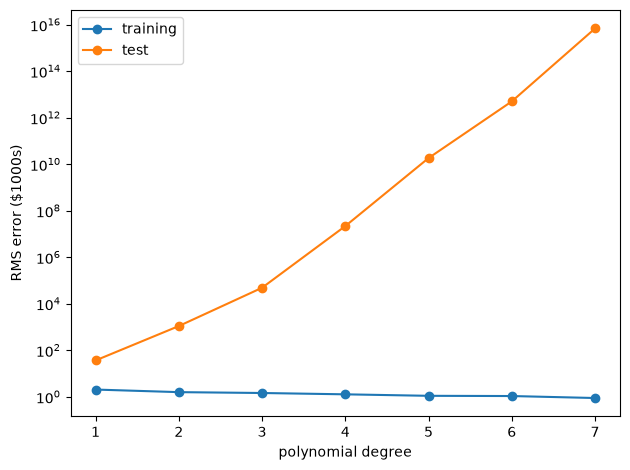

In [11]:
# answer to 1A
fig, ax = plt.subplots()
ax.plot(range(1, 8), train_errors, marker='o', label="training")
ax.plot(range(1, 8), test_errors, marker='o', label="test")
ax.set_yscale("log") # switching to logarithmic here because the test errors span from 36 to 6.9e15 visibility purposes
ax.set_xlabel("polynomial degree")
ax.set_ylabel("RMS error ($1000s)") # Median value of owner occupied homes in $1000s
ax.legend()
plt.tight_layout()
fig.savefig("media/poly-degree-error.png", dpi=110)

In [12]:
# 1B
w1 = fit(design_matrix(training_data_Xn, 1), training_data_Y)
print("RM", w1[6], std[5])
print("DIS", w1[8], std[7])

# RM moves the prediction by 4200 dollars per std and since one std is abut half a room, thats like 8600 per extra room.
# DIS moves it by about $11 per std, so distance to employment centres is negligible.

Phi_dis = design_matrix(training_data_Xn[:, 7:8], 1)
w_dis = fit(design_matrix(training_data_Xn[:, 7:8], 1), training_data_Y)
print("DIS alone", w_dis[1], rms_error(Phi_dis, w_dis, training_data_Y))
print("baseline", training_data_Y.std())


# When we do DIS along, the weight falls from 0.94 to 0.01 once the other twelve features join, which is absorption
# A near zero-weight in a multi feature model never proves its irrelevance by itself.

RM 4.1956343858302185 0.48837776556677914
DIS 0.010715449340661029 1.4049975245028015
DIS alone 0.9417691760476554 5.822584462165106
baseline 5.898255589579008


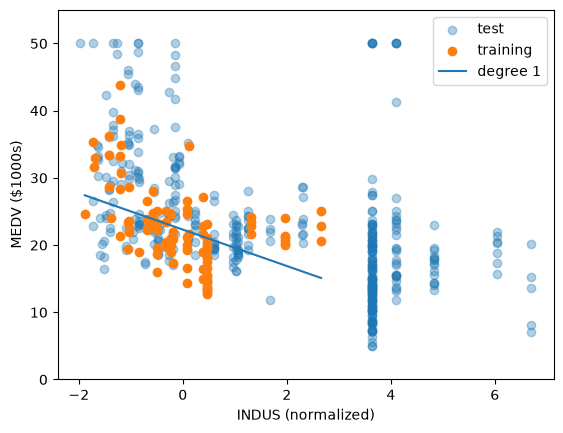

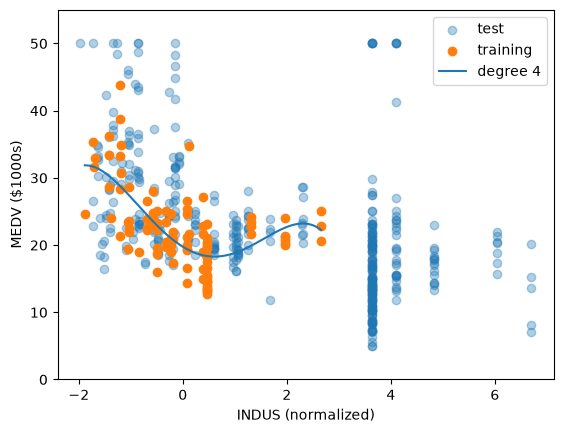

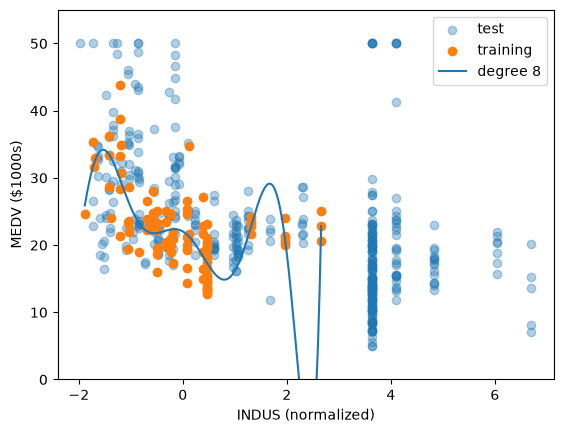

In [13]:
#1C
def polynomial_regression_1d_vis(feature_index, order, filename):
    x_train = training_data_Xn[:, feature_index:feature_index + 1]
    x_test = test_data_Xn[:, feature_index:feature_index + 1]

    w = fit(design_matrix(x_train, order), training_data_Y)

    grid = np.linspace(x_train.min(), x_train.max(), 300).reshape(-1, 1)
    curve = design_matrix(grid, order) @ w

    fig, ax = plt.subplots()
    ax.scatter(x_test, test_data_Y, alpha=0.35, label="test")
    ax.scatter(x_train, training_data_Y, label="training")
    ax.plot(grid, curve, label=f"degree {order}")

    ax.set_xlabel(f"{names[feature_index]} (normalized)")
    ax.set_ylabel("MEDV ($1000s)")
    ax.set_ylim(0, 55)
    ax.legend()
    fig.savefig("media/" + filename)

for o in (1, 4, 8):
    polynomial_regression_1d_vis(2, o, f"indus-degree-{o}.png")

In [17]:
# 1D
def ridge_fit(Phi, y, lam):
    # least squares weights, but big weights cost lam each
    I = np.eye(Phi.shape[1])
    I[0, 0] = 0.0
    # bias is not penalized
    return np.linalg.solve(Phi.T @ Phi + lam * I, Phi.T @ y)

def polynomial_regression_reg(x, order, lambdas, folds):
    shuffled = np.random.default_rng(0).permutation(len(x))
    means = []
    for lam in lambdas:
        errs = []
        for part in np.array_split(shuffled, folds):
            val = np.zeros(len(x), dtype=bool)
            val[part] = True
            w = ridge_fit(design_matrix(x[~val], order), training_data_Y[~val], lam)
            errs.append(rms_error(design_matrix(x[val], order), w, training_data_Y[val]))
        means.append(np.mean(errs))
    return means

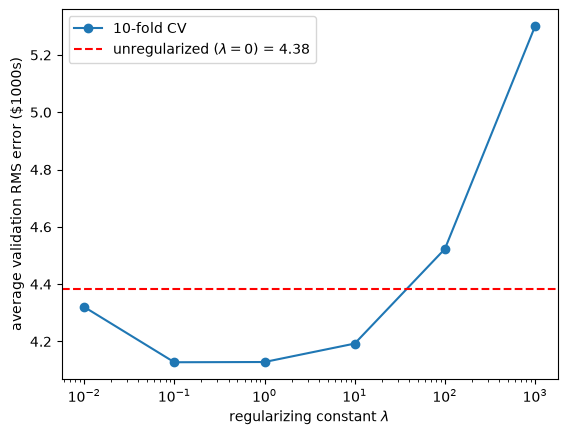

In [18]:
lambdas = [0, 0.01, 0.1, 1, 10, 100, 1000]
cv = polynomial_regression_reg(training_data_Xn[:, 2:3], 8, lambdas, 10)

fig, ax = plt.subplots()
ax.plot(lambdas[1:], cv[1:], marker="o", label="10-fold CV")
ax.axhline(cv[0], color="red", linestyle="--",label=f"unregularized ($\\lambda=0$) = {cv[0]:.2f}")
ax.set_xscale("log")
ax.set_xlabel("regularizing constant $\\lambda$")
ax.set_ylabel("average validation RMS error ($1000s)")
ax.legend()
fig.savefig("media/reg-cv.png", dpi=110, bbox_inches="tight")

In [19]:
# 2E
def gaussian_design_matrix(A, centers, s):
    # squared distance from every row of A to every center across all 13 features
    d2 = np.zeros((len(A), len(centers)))
    for j, c in enumerate(centers):
        d2[:, j] = ((A - c) ** 2).sum(axis=1)
    return np.column_stack([np.ones(len(A)), np.exp(-d2 / (2 * s ** 2))])


def gaussian_regression(Ks):
    shuffled = np.random.default_rng(0).permutation(len(training_data_Xn))
    train_errors, test_errors = [], []
    
    for K in Ks:
        centers = training_data_Xn[shuffled[:K]]
        Phi_train = gaussian_design_matrix(training_data_Xn, centers, 1)
        Phi_test = gaussian_design_matrix(test_data_Xn, centers, 1)
        
        w = fit(Phi_train, training_data_Y)
        
        train_errors.append(rms_error(Phi_train, w, training_data_Y))
        test_errors.append(rms_error(Phi_test, w, test_data_Y))
    return train_errors, test_errors

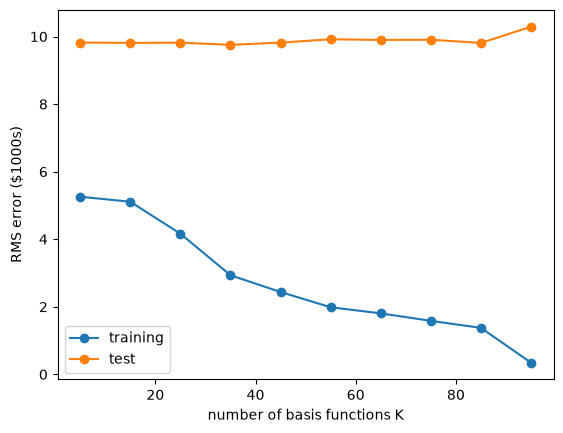

In [20]:
Ks = list(range(5, 100, 10))
train_errors, test_errors = gaussian_regression(Ks)

fig, ax = plt.subplots()
ax.plot(Ks, train_errors, marker="o", label="training")
ax.plot(Ks, test_errors, marker="o", label="test")
ax.set_xlabel("number of basis functions K")
ax.set_ylabel("RMS error ($1000s)")
ax.legend()
fig.savefig("media/gaussian-k-error.png", dpi=110, bbox_inches="tight")

In [23]:
# 2F
def gaussian_regression_reg(K, lambdas, folds):
    x = training_data_Xn
    shuffled = np.random.default_rng(0).permutation(len(x))
    means = []
    for lam in lambdas:
        errs = []
        for part in np.array_split(shuffled, folds):
            val = np.zeros(len(x), dtype=bool)
            val[part] = True
            centers = x[~val][:K]
            
            Phi_t = gaussian_design_matrix(x[~val], centers, 1)
            Phi_v = gaussian_design_matrix(x[val], centers, 1)
            
            # lambda 0 is singular here, so lstsq instead of ridge_fit
            w = fit(Phi_t, training_data_Y[~val]) if lam == 0 else ridge_fit(Phi_t, training_data_Y[~val], lam)
            
            errs.append(rms_error(Phi_v, w, training_data_Y[val]))
        means.append(np.mean(errs))
    return means

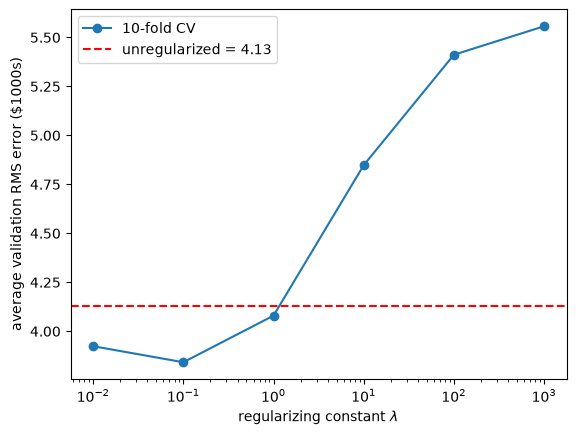

In [24]:
lambdas = [0, 0.01, 0.1, 1, 10, 100, 1000]
cv = gaussian_regression_reg(90, lambdas, 10)

fig, ax = plt.subplots()
ax.plot(lambdas[1:], cv[1:], marker="o", label="10-fold CV")
ax.axhline(cv[0], color="red", linestyle="--", label=f"unregularized = {cv[0]:.2f}")
ax.set_xscale("log")
ax.set_xlabel("regularizing constant $\\lambda$")
ax.set_ylabel("average validation RMS error ($1000s)")
ax.legend()
fig.savefig("media/gaussian-reg-cv.png", dpi=110, bbox_inches="tight")